In [11]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2 as cv

In [12]:
# Directorio de entrada y salida
carpeta_imagenes = '/home/telematica/Desktop/DAC/APTOS/Peorcitas'  # Cambia esta ruta a la ubicación de tu carpeta de imágenes
carpeta_salida = '/home/telematica/Desktop/DAC/APTOS/Salida canny'   # Cambia esta ruta a donde quieras guardar las imágenes procesadas

In [13]:
# Parámetros de Canny Edge Detection
lower_threshold = 30
upper_threshold = 70

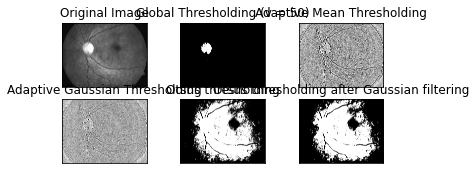

In [29]:
# Crear la carpeta de salida si no existe
if not os.path.exists(carpeta_salida):
   os.makedirs(carpeta_salida)

# Crear un objeto CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# Parámetros de Canny Edge Detection
lower_threshold = 30
upper_threshold = 70

# Filtrar solo archivos de imagen
formatos_validos = (".jpg", ".png", ".jpeg")

# Iterar sobre todas las imágenes en la carpeta de entrada
for archivo_imagen in os.listdir(carpeta_imagenes):
    if archivo_imagen.endswith(formatos_validos):
        ruta_imagen = os.path.join(carpeta_imagenes, archivo_imagen)
        
        # Cargar la imagen en color
        imagen = cv2.imread(ruta_imagen)
        
        # Extraer solo el canal verde
        canal_rojo = imagen[:, :, 2]
        
        # Aplicar CLAHE al canal verde
        canal_Rojo_clahe = clahe.apply(canal_rojo)
        
        # Aplicar Canny Edge Detection al canal verde con CLAHE
        #edges = cv2.Canny(canal_Rojo_clahe, lower_threshold, upper_threshold)
          
        ret,th1 = cv.threshold(canal_Rojo_clahe,180,255,cv.THRESH_BINARY)
        th2 = cv.adaptiveThreshold(canal_Rojo_clahe,255,cv.ADAPTIVE_THRESH_MEAN_C,\
            cv.THRESH_BINARY,23,2)
        th3 = cv.adaptiveThreshold(canal_Rojo_clahe,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv.THRESH_BINARY,23,2)
        
        # Otsu's thresholding
ret2,th4 = cv.threshold(canal_Rojo_clahe,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
 
# Otsu's thresholding after Gaussian filtering
blur = cv.GaussianBlur(canal_Rojo_clahe,(5,5),0)
ret3,th5 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
        # Convertir la imagen de bordes a BGR para combinarla con las otras
       # edges_bgr = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
        
        # Convertir el canal verde CLAHE a BGR para visualizarlo
        #clahe_imagen_bgr = cv2.cvtColor(canal_Rojo_clahe, cv2.COLOR_GRAY2BGR)
        
 
        # Agregar el nombre en la imagen original
      #  cv2.putText(imagen, 'Original: ' + archivo_imagen, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        
        # Agregar el nombre en la imagen CLAHE del canal verde
      #  cv2.putText(clahe_imagen_bgr, 'CLAHE (Rojo): ' + archivo_imagen, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        
        # Agregar el nombre en la imagen de bordes
       # cv2.putText(edges_bgr, 'Canny (Rojo CLAHE): ' + archivo_imagen, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        
        # Combinar la imagen original, CLAHE del canal verde y bordes horizontalmente
        # imagen_combined = np.hstack((imagen,canal_Rojo_clahe,th1,th2,th3))
        
         
titles = ['Original Image', 'Global Thresholding (v = 50)',
            'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding','Otsus thresholding','Otsus thresholding after Gaussian filtering']
images = [canal_Rojo_clahe, th1, th2, th3,th4,th5]
 
for i in range(6):
    plt.subplot(3,3,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()
 # Guardar la imagen combinada en la carpeta de salida
#salida_path = os.path.join(carpeta_salida, f"comparacion_{archivo_imagen}")
#cv2.imwrite(salida_path, imagen_combined)
#print(f"Imagen combinada guardada en: {salida_path}")

#print("Procesamiento de imágenes completado.")